In [4]:
import pandas as pd

In [16]:
# Загружаем лист Monthly_Performance
panel = pd.read_excel('C:/Users/umed/Desktop/Inflow_тренировочные_данные.xlsx', sheet_name='Monthly_Performance')

# Проверяем
panel.head()
panel['snapshot_month'].unique()
# ['2025-01' '2025-02' '2025-03' '2025-04' '2025-05' '2025-06']

panel['dpd_bucket'].unique()
# ['Current' 'PaidOff' '1-30' '31-60' '61-90' '90+']

<StringArray>
['Current', 'PaidOff', '1-30', '31-60', '61-90', '90+']
Length: 6, dtype: str

In [17]:
panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 1735 entries, 0 to 1734
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   loan_id         1735 non-null   str  
 1   snapshot_month  1735 non-null   str  
 2   balance         1735 non-null   int64
 3   dpd_bucket      1735 non-null   str  
dtypes: int64(1), str(3)
memory usage: 54.3 KB


In [18]:
def inflow_1plus(panel, month_prev, month_curr):
    # 1. База: Current на T-1 знаменатель 
    base = panel[(panel['snapshot_month'] == month_prev) & (panel['dpd_bucket'] == 'Current')]
    base_ids = set(base['loan_id'])
    denominator = base['balance'].sum()
    
    # 2. Те же кредиты на T 
    next_m = panel[(panel['snapshot_month'] == month_curr) & (panel['loan_id'].isin(base_ids))]
    
    # 3. Из них — только те, у кого dpd_bucket != 'Current'
    #    ВАЖНО: исключаем PaidOff — это не просрочка
    numerator_df = next_m[(next_m['dpd_bucket'] != 'Current') & (next_m['dpd_bucket'] != 'PaidOff')]
    numerator = numerator_df['balance'].sum()
    
    # 4. Inflow
    inflow = numerator / denominator if denominator > 0 else 0
    
    return {
        'period': f'{month_prev} → {month_curr}',
        'month_T': month_curr,
        'denominator': denominator,
        'numerator': numerator,
        'inflow_1plus': inflow,
        'n_base': len(base),
        'n_bad': len(numerator_df)
    }       

In [19]:
pairs = [
    ('2025-01', '2025-02'),
    ('2025-02', '2025-03'),
    ('2025-03', '2025-04'),
    ('2025-04', '2025-05'),
    ('2025-05', '2025-06'),
]

results = []
for prev, curr in pairs:
    r = inflow_1plus(panel, prev, curr)
    results.append(r) # Результат функции добавыляем в массив данных

df_inflow = pd.DataFrame(results)
df_inflow

,period,month_T,denominator,numerator,inflow_1plus,n_base,n_bad
0,2025-01 → 2025-02,2025-02,1231000,46560,0.037823,90,4
1,2025-02 → 2025-03,2025-03,1768140,115630,0.065396,130,9
2,2025-03 → 2025-04,2025-04,2923220,229800,0.078612,212,19
3,2025-04 → 2025-05,2025-05,3918040,267680,0.068320,280,21
4,2025-05 → 2025-06,2025-06,5588960,464330,0.083080,400,31


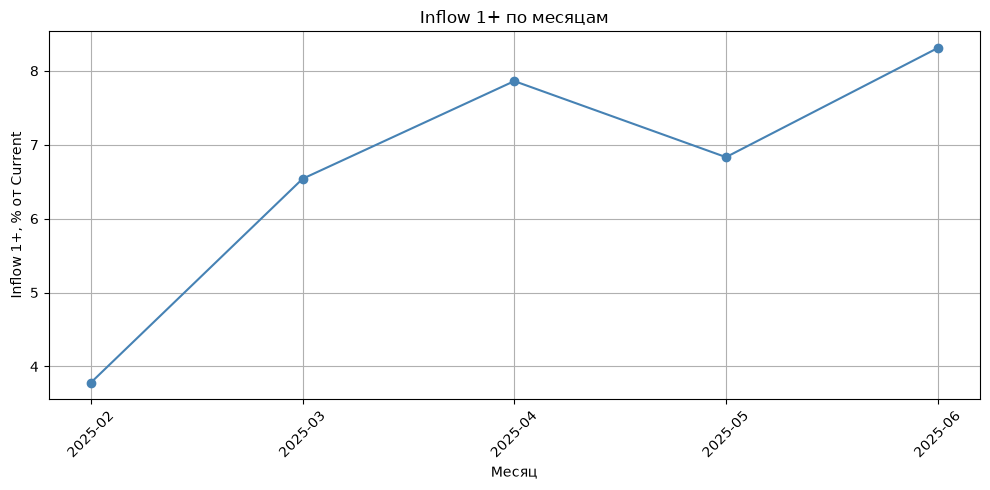

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_inflow['month_T'], df_inflow['inflow_1plus'] * 100, marker='o', color='steelblue')
plt.title('Inflow 1+ по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Inflow 1+, % от Current')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()